In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt 

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats

Loading the data

In [5]:
url = "https://raw.githubusercontent.com/NoorAbdulAziz/Data/main/Iris.csv"

data = pd.read_csv(url)

data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
#Number of rows
print(data.shape[0])

#Number of columns
print(data.shape[1])

#Column names
print(data.columns)

#Data types
print(data.dtypes)

150
6
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object


replace portion of species name 

In [14]:
data['Species'] = data['Species'].str.replace('Iris-', '')

data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


- The number of each species present
- The mean, mediain, and quantile and ranges for each petal and sepal measurement.


In [15]:
data.Species.value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [17]:
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['mean', '25%', '50%', '75%','range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
mean,75.50,5.843333,3.054,3.758667,1.198667
25%,38.25,5.100000,2.800,1.600000,0.300000
median,75.50,5.800000,3.000,4.350000,1.300000
75%,112.75,6.400000,3.300,5.100000,1.800000
range,149.00,3.600000,2.400,5.900000,2.400000


In [18]:
# The mean calculation
data.groupby('Species').mean()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
setosa,25.5,5.006,3.418,1.464,0.244
versicolor,75.5,5.936,2.770,4.260,1.326
virginica,125.5,6.588,2.974,5.552,2.026


In [19]:
# The median calculation
data.groupby('Species').median()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
setosa,25.5,5.0,3.4,1.50,0.2
versicolor,75.5,5.9,2.8,4.35,1.3
virginica,125.5,6.5,3.0,5.55,2.0


In [21]:
data.groupby('Species').agg(['mean', 'median'])
data.groupby('Species').agg([np.mean, np.median])

Id        SepalLengthCm        SepalWidthCm         \
             mean median          mean median         mean median   
Species                                                             
setosa       25.5   25.5         5.006    5.0        3.418    3.4   
versicolor   75.5   75.5         5.936    5.9        2.770    2.8   
virginica   125.5  125.5         6.588    6.5        2.974    3.0   

           PetalLengthCm        PetalWidthCm         
                    mean median         mean median  
Species                                              
setosa             1.464   1.50        0.244    0.2  
versicolor         4.260   4.35        1.326    1.3  
virginica          5.552   5.55        2.026    2.0

In [24]:
from pprint import pprint

agg_dict = {field: ['mean', 'median'] for field in data.columns if field != 'Species'}
agg_dict['PetalLengthCm'] = 'max'
pprint(agg_dict)
data.groupby('Species').agg(agg_dict)

{'Id': ['mean', 'median'],
 'PetalLengthCm': 'max',
 'PetalWidthCm': ['mean', 'median'],
 'SepalLengthCm': ['mean', 'median'],
 'SepalWidthCm': ['mean', 'median']}


Id        SepalLengthCm        SepalWidthCm         \
             mean median          mean median         mean median   
Species                                                             
setosa       25.5   25.5         5.006    5.0        3.418    3.4   
versicolor   75.5   75.5         5.936    5.9        2.770    2.8   
virginica   125.5  125.5         6.588    6.5        2.974    3.0   

           PetalLengthCm PetalWidthCm         
                     max         mean median  
Species                                       
setosa               1.9        0.244    0.2  
versicolor           5.1        1.326    1.3  
virginica            6.9        2.026    2.0

Make a scatter plot of  `sepal_lenght` vs `sepal_width` using Matplotlib. Label the axes and give the plot a title

[Text(0.5, 0, 'Petal Length (cm)'),
 Text(0, 0.5, 'Petal Width (cm)'),
 Text(0.5, 1.0, 'Petal Length vs Petal Width')]

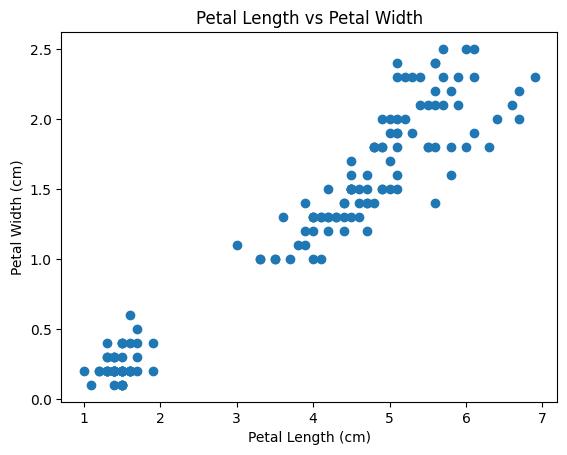

In [25]:
import matplotlib.pyplot as plt

ax = plt.axes()

ax.scatter(data.PetalLengthCm, data.PetalWidthCm)

ax.set(xlabel='Petal Length (cm)', ylabel='Petal Width (cm)', title='Petal Length vs Petal Width')

In [ ]:
Make a histogram of any one of the four features. Label axes and title it as appropriate.

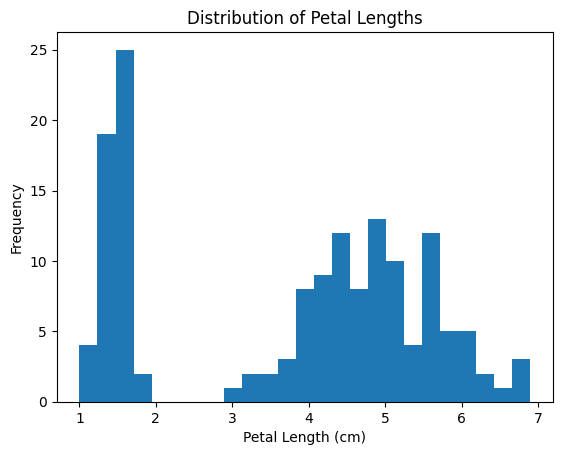

In [26]:
# Using Matplotlib's plotting functionality
ax = plt.axes()
ax.hist(data.PetalLengthCm, bins=25);

ax.set(xlabel='Petal Length (cm)', 
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

Plotting histogram while using pandas plot funtion

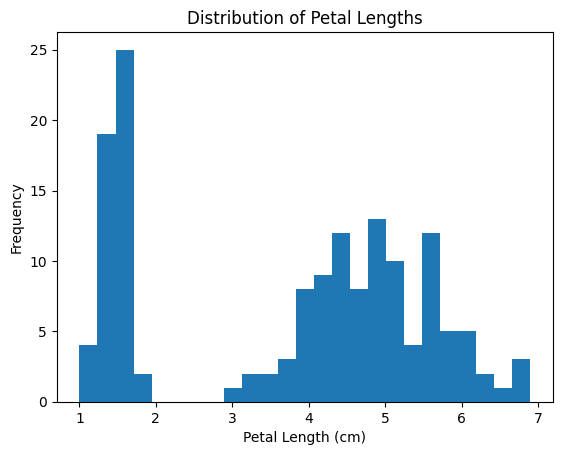

In [27]:
ax = data.PetalLengthCm.plot.hist(bins=25)

ax.set(xlabel='Petal Length (cm)', 
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

In [ ]:
#creating a single plot with histograms for all four features.

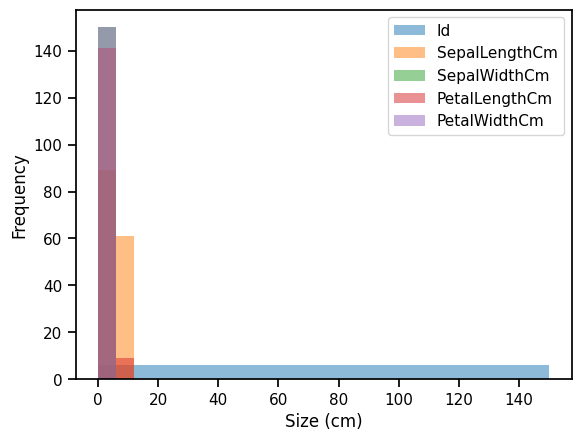

In [28]:
import seaborn as sns
sns.set_context('notebook')

ax = data.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('Size (cm)');

AttributeError: 'Axes' object has no attribute 'is_last_row'

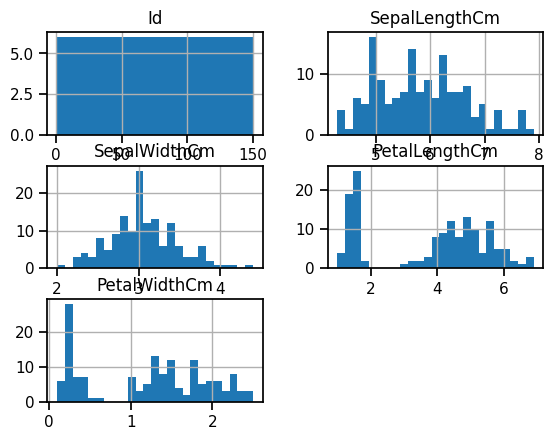

In [29]:
axList = data.hist(bins=25)

for ax in axList.flatten():
    if ax.is_last_row():
        ax.set_xlabel('Size (cm)')
    
    if ax.is_first_col():
        ax.set_ylabel('Frequency')

using Pandas, make a boxplot of each petal and sepal measurement.

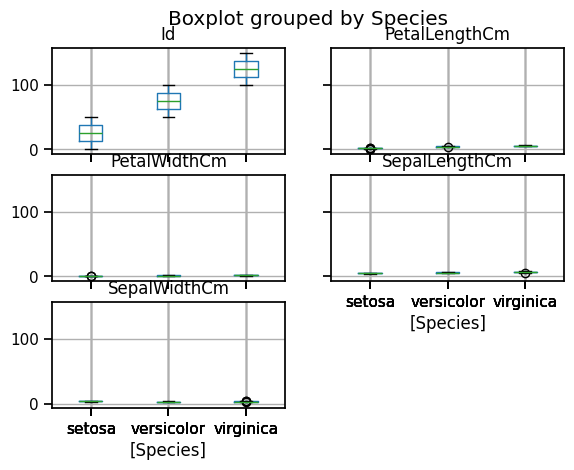

In [30]:
data.boxplot(by='Species');

Now make a single boxplot where the features are separated in the x-axis and species are colored with different hues.

In [32]:
plot_data = (data
             .set_index('Species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()

,Species,measurement,size
0,setosa,Id,1.0
1,setosa,SepalLengthCm,5.1
2,setosa,SepalWidthCm,3.5
3,setosa,PetalLengthCm,1.4
4,setosa,PetalWidthCm,0.2


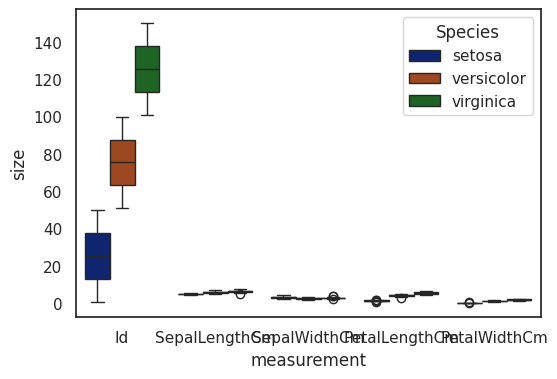

In [33]:
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size', 
            hue='Species', data=plot_data);

Make a pairplot with Seaborn to examine the correlation between each of the measurements.

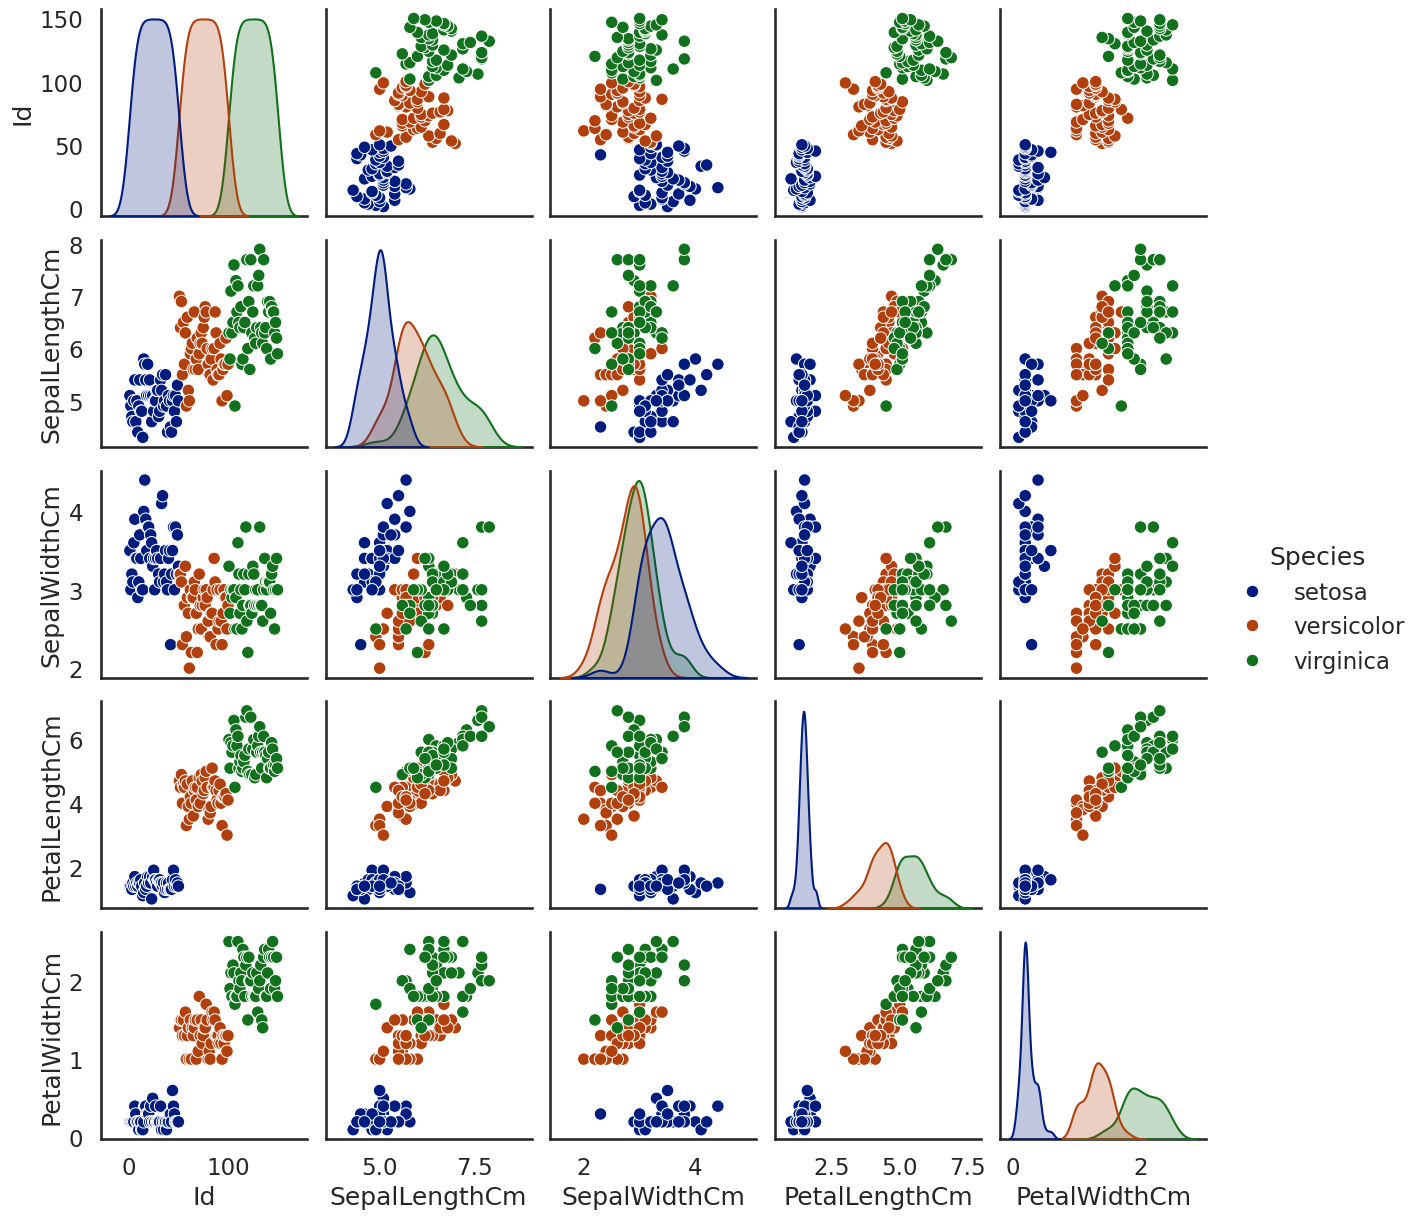

In [35]:
sns.set_context('talk')
sns.pairplot(data, hue='Species');